In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# BCELoss

In [6]:
loss_fn = nn.BCELoss(reduction='sum')

In [7]:
x = torch.rand(5) # input, values [0,1]
y = torch.rand(5) # target, values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(x_i) + (1 - y_i) * torch.log(1 - x_i))

loss, s

(tensor(3.8241), tensor(3.8241))

In [9]:
x = torch.rand((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(x_i_j) + (1 - y_i_j) * torch.log(1 - x_i_j))

loss, s

(tensor(29.0460), tensor(29.0460))

# BCEWithLogitsLoss

In [ ]:
loss_fn = nn.BCEWithLogitsLoss(reduction='sum')

In [3]:
x = torch.randn(10) # input, both negative and positive values
y = torch.rand(10) # target, contains values [0,1]
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    s -= (y_i * torch.log(F.sigmoid(x_i)) + (1 - y_i) * torch.log(1 - F.sigmoid(x_i)))

loss, s

(tensor(8.3882), tensor(8.3882))

In [5]:
x = torch.randn((3, 10))
y = torch.rand((3, 10))
loss = loss_fn(x, y)

s = 0

for x_i, y_i in zip(x, y):
    for x_i_j, y_i_j in zip(x_i, y_i):
        s -= (y_i_j * torch.log(F.sigmoid(x_i_j)) + (1 - y_i_j) * torch.log(1 - F.sigmoid(x_i_j)))

loss, s

(tensor(23.5631), tensor(23.5631))

# BCELoss vs MSELoss

In [17]:
bce_loss = nn.BCELoss()
mse_loss = nn.MSELoss()

xx, yy = np.meshgrid(np.linspace(0.01, 0.99, 100), np.linspace(0.01, 0.99, 100))
xx = torch.Tensor(xx)
yy = torch.Tensor(yy)
bce_zz = []
mse_zz = []

for x, y in zip(xx.ravel(), yy.ravel()):
    bce_zz.append(bce_loss(y, x))
    mse_zz.append(mse_loss(y, x))

bce_zz = np.array(bce_zz).reshape(xx.shape)
mse_zz = np.array(mse_zz).reshape(xx.shape)

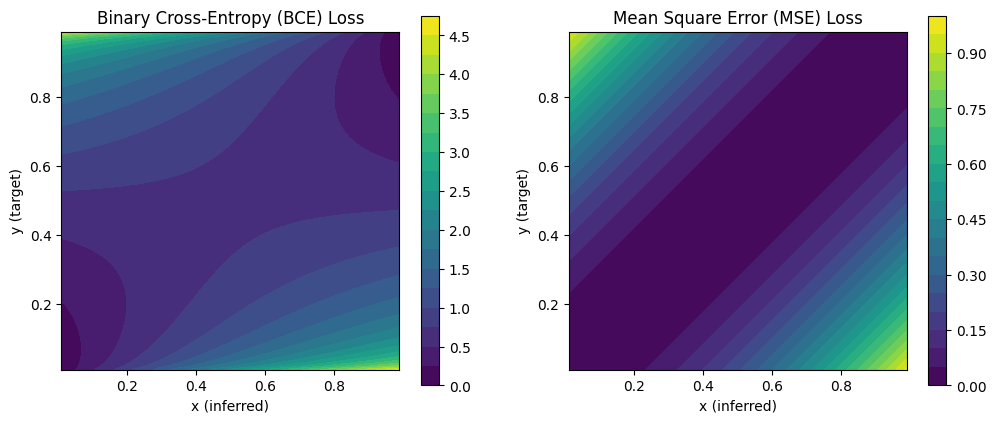

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(12)

im = ax1.contourf(xx, yy, bce_zz, levels=20, cmap='viridis')
ax1.set_aspect('equal')
ax1.set_xlabel('x (inferred)')
ax1.set_ylabel('y (target)')
ax1.set_title('Binary Cross-Entropy (BCE) Loss')
fig.colorbar(im, ax=ax1);

im = ax2.contourf(xx, yy, mse_zz, levels=20, cmap='viridis')
ax2.set_aspect('equal')
ax2.set_xlabel('x (inferred)')
ax2.set_ylabel('y (target)')
ax2.set_title('Mean Square Error (MSE) Loss')
fig.colorbar(im, ax=ax2);